In [4]:
!pip install ucimlrepo
!pip install matplotlib seaborn scikit-learn pandas


import pandas as pd
from ucimlrepo import fetch_ucirepo  #load the actual dataset from the UCI repository
steel_plates_faults = fetch_ucirepo(id=198)  #fetch the dataset using its UCI ID (198)

X_raw = steel_plates_faults.data.features  #extract features and targets as pandas dataframes
y_raw = steel_plates_faults.data.targets
df = pd.concat([X_raw, y_raw], axis=1) #combine them into a single DataFrame

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print(df.head())  #display rows



   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.0 MB 16.8 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.0 MB 1.5 MB/s eta 0:00:03
   -----

In [5]:
# Data Loading & Preprocessing
fault_columns = ['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

# Label Transformation: The raw dataset encodes the 7 defect types as 7 separate columns (One-Hot Encoded). 
# We must reverse this into a single Fault_Type column for a standard Decision Tree.
df['Fault_Type'] = df[fault_columns].idxmax(axis=1)
df = df.drop(columns=fault_columns)

# Define features (X) and Target (y)
X = df.drop(columns=['Fault_Type'])
y = df['Fault_Type']


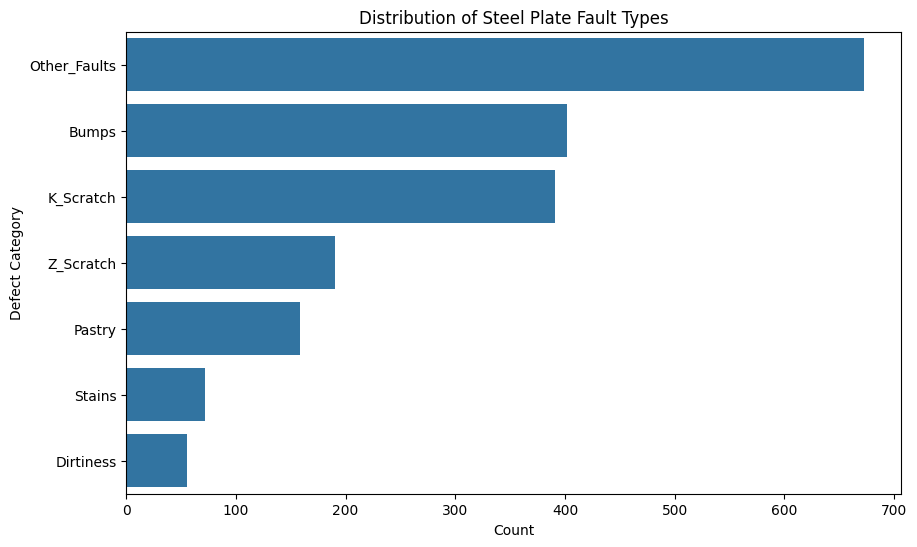

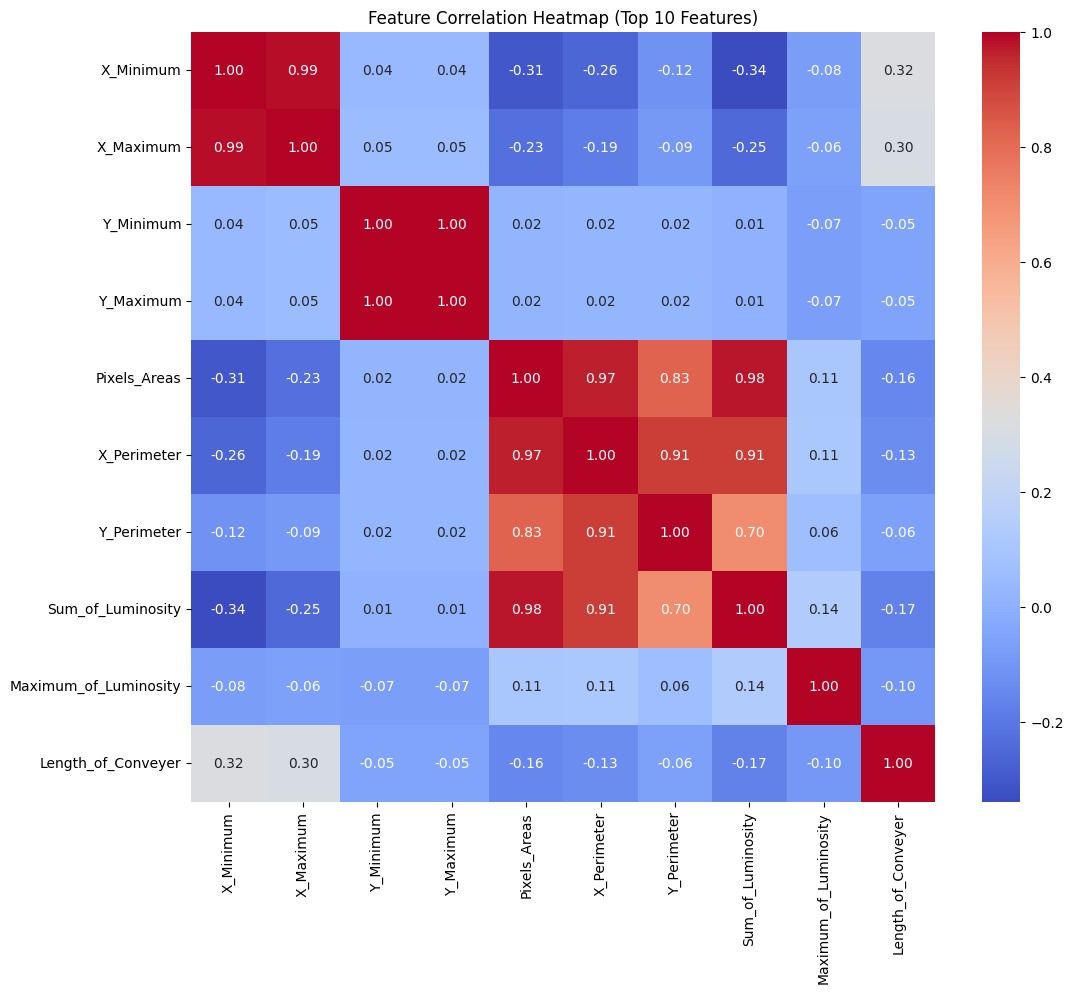

In [6]:
#  Exploratory Data Analysis (EDA)
plt.figure(figsize=(10, 6))   # Class Imbalance Check
sns.countplot(data=df, y='Fault_Type', order=df['Fault_Type'].value_counts().index)
plt.title('Distribution of Steel Plate Fault Types')
plt.xlabel('Count')
plt.ylabel('Defect Category')
plt.show()

#correlation Analysis
#checking if certain camera metrics are highly correlated.
plt.figure(figsize=(12, 10))
#plotting correlation for a subset of features to keep it readable
sns.heatmap(X.iloc[:, :10].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap (Top 10 Features)')
plt.show()


# Calculate the physical dimensions of the defect bounding box.
X['Defect_Width'] = X['X_Maximum'] - X['X_Minimum']
X['Defect_Length'] = X['Y_Maximum'] - X['Y_Minimum']
X['Bounding_Box_Area'] = X['Defect_Width'] * X['Defect_Length']


#  Calculate Defect Density (Pixels_Areas / Bounding Box Area)
# Hint: Add + 1e-5 to the denominator to prevent Division by Zero errors!
X['Defect_Density'] = X['Pixels_Areas'] / (X['Bounding_Box_Area'] + 1e-5)




In [7]:
# Feature Engineering (Adding Physical Context)
#A Decision Tree struggles to "connect" individual bounding box coordinates to understand actual size.

In [8]:

# Train-Test Split & Model Setup

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Decision Tree
# set parameter, e.g set max_depth=5 to prevent the tree from overfitting the factory data
dt_model = DecisionTreeClassifier(
    max_depth=5,  #restricting depth to prevent overfitting and instability
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no


Model Accuracy on Unseen Plates: 64.52%

Detailed Quality Control Report:
              precision    recall  f1-score   support

       Bumps       0.47      0.78      0.59        72
   Dirtiness       0.00      0.00      0.00         8
   K_Scratch       1.00      0.78      0.88        83
Other_Faults       0.66      0.48      0.56       143
      Pastry       0.24      0.41      0.30        29
      Stains       1.00      0.92      0.96        13
   Z_Scratch       0.93      0.90      0.91        41

    accuracy                           0.65       389
   macro avg       0.61      0.61      0.60       389
weighted avg       0.69      0.65      0.65       389



c:\Users\clabe\anaconda3\envs\clari\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\clabe\anaconda3\envs\clari\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\clabe\anaconda3\envs\clari\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

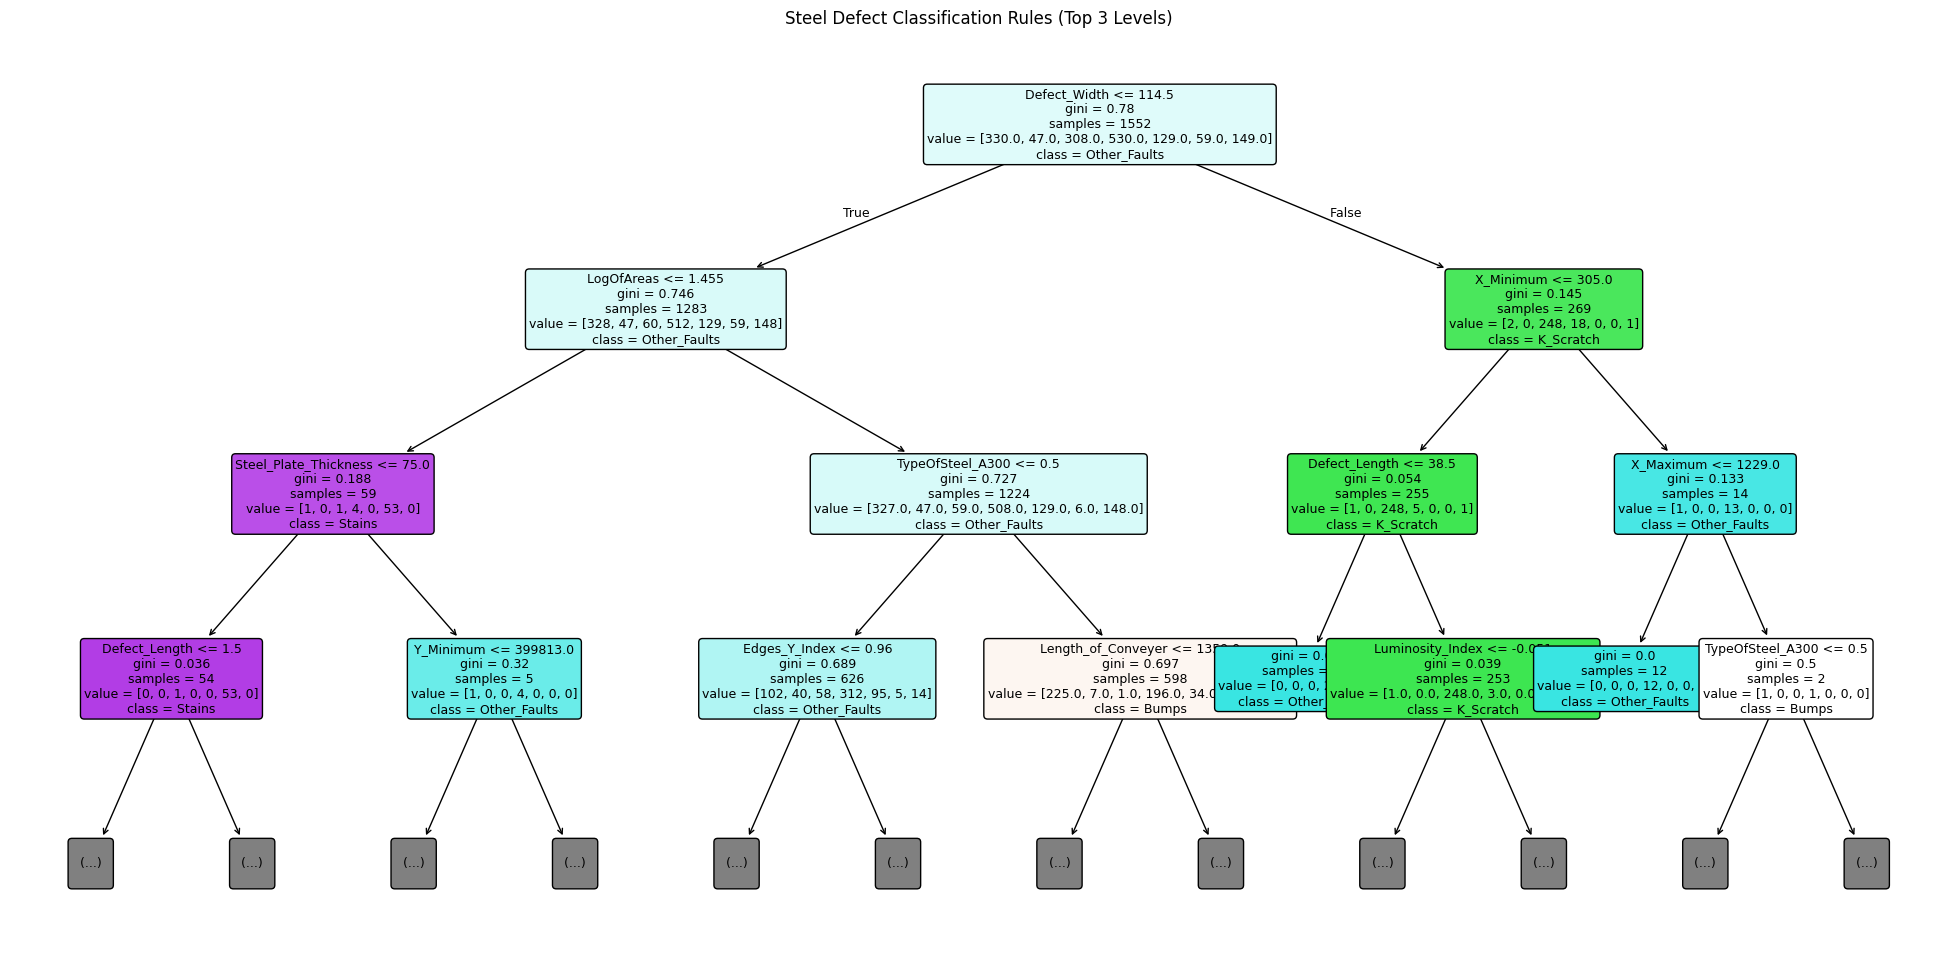

In [9]:

#  Evaluation & QC Report
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Unseen Plates: {accuracy * 100:.2f}%")

print("\nDetailed Quality Control Report:")
print(classification_report(y_test, y_pred))

# Visualizing the "Business Rules"
plt.figure(figsize=(25, 12))
plot_tree(
    dt_model, 
    feature_names=X.columns, 
    class_names=[str(c) for c in dt_model.classes_], 
    filled=True, 
    rounded=True,
    max_depth=3, # Only plotting top 3 levels for readability
    fontsize=9
)
plt.title("Steel Defect Classification Rules (Top 3 Levels)")
plt.show()